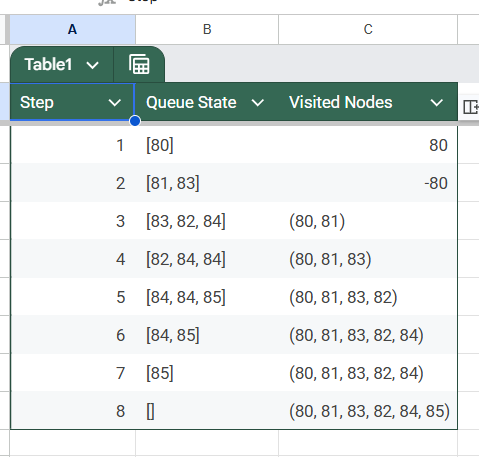

Final BFS Order: 80 → 81 → 83 → 82 → 84 → 85

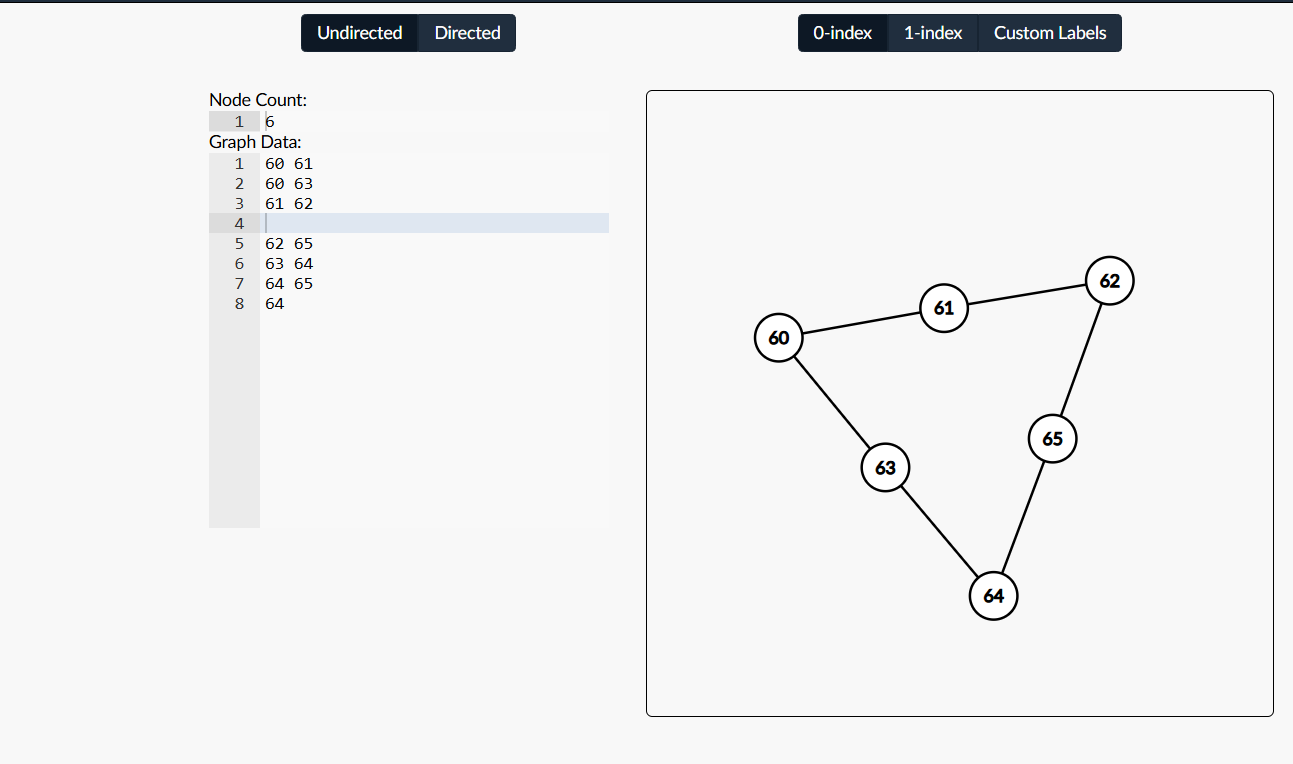

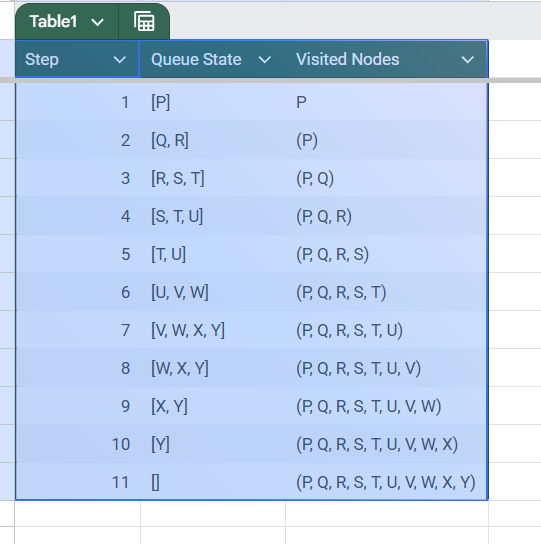

Final BFS Order: P → Q → R → S → T → U → V → W → X → Y

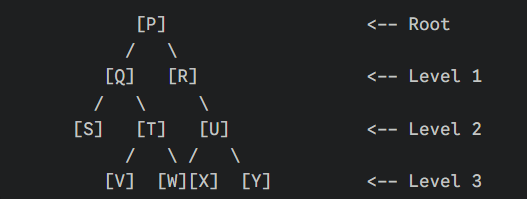

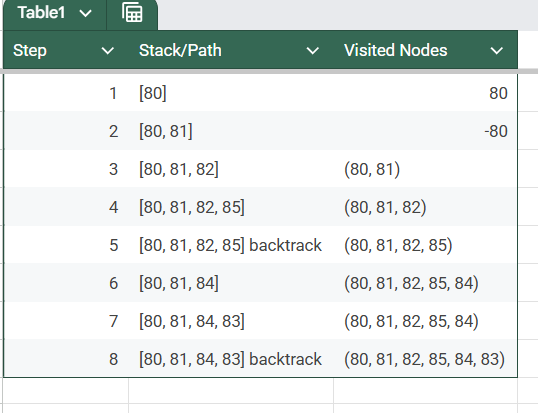

Final DFS Order: 80 → 81 → 82 → 85 → 84 → 83

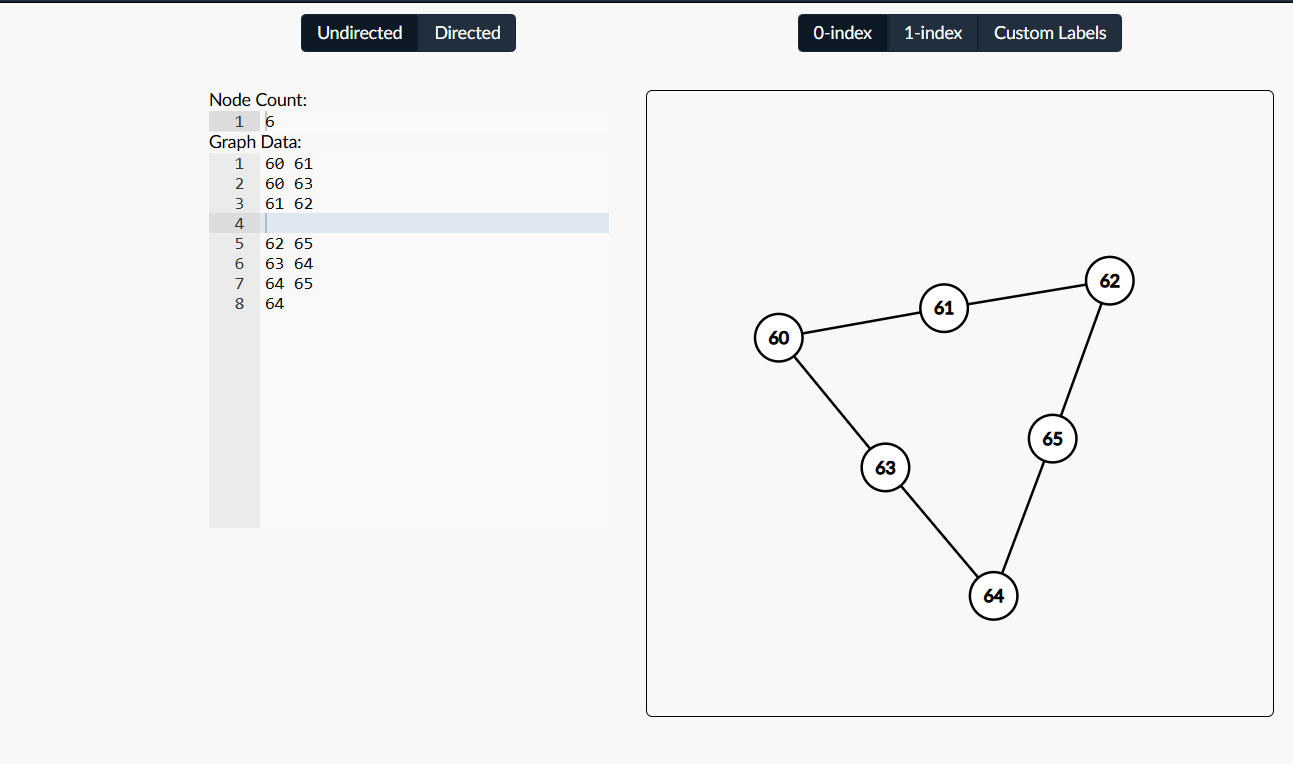

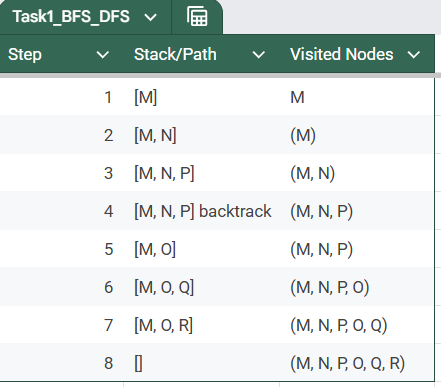

Final DFS Order (Alphabetical): M → N → P → O → Q → R

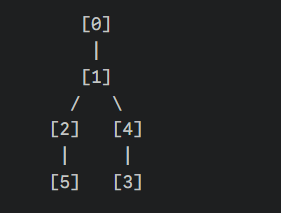

Processing size: 1000...
Processing size: 40000...
Processing size: 80000...
Processing size: 200000...
Processing size: 1000000...

--- Experiment Results ---
   Tree Size  BFS Time (s)  DFS Time (s)
0       1000      0.000072      0.000090
1      40000      0.008886      0.012479
2      80000      0.027731      0.026353
3     200000      0.042798      0.045096
4    1000000      0.068866      0.241339


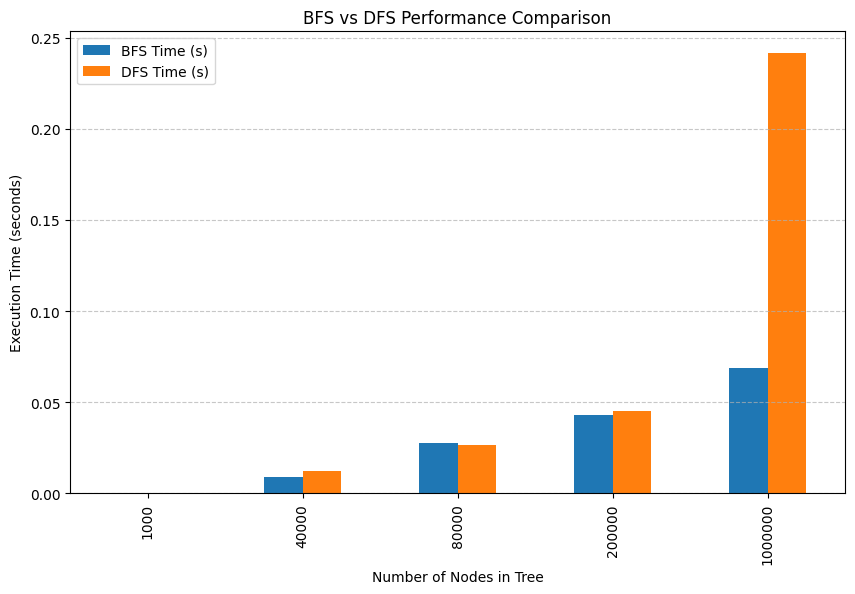

In [1]:
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

# 1. Node Class: Added double underscores to __init__ [cite: 118-125]
class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None

# 2. Balanced Tree Builder [cite: 127-137]
def build_tree(data):
    if not data:
        return None
    mid = len(data) // 2
    root = Node(data[mid])
    root.left = build_tree(data[:mid])
    root.right = build_tree(data[mid+1:])
    return root

# 3. BFS Implementation (Level-order search) [cite: 139-152]
def bfs(root, goal):
    start_time = time.perf_counter()
    queue = deque([root])
    while queue:
        node = queue.popleft() # Fixed 'nade' typo from original
        if node.key == goal:
            break
        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)
    return time.perf_counter() - start_time

# 4. DFS Implementation (Depth-first search using stack) [cite: 154-168]
def dfs(root, goal):
    start_time = time.perf_counter()
    stack = [root]
    while stack:
        node = stack.pop()
        if node.key == goal:
            break
        # To mimic standard DFS, we push right then left so left is popped first
        if node.right:
            stack.append(node.right)
        if node.left:
            stack.append(node.left)
    return time.perf_counter() - start_time

# 5. Experiment Setup [cite: 170-179]
tree_sizes = [1000, 40000, 80000, 200000, 1000000]
bfs_times = []
dfs_times = []

for size in tree_sizes:
    print(f"Processing size: {size}...")
    # Generating unique random data and sorting it for a balanced tree
    data = sorted(random.sample(range(1, size * 10), size))
    root = build_tree(data)

    # Selecting a goal node (near the end of the tree) [cite: 177]
    goal = data[-220]

    bfs_times.append(bfs(root, goal))
    dfs_times.append(dfs(root, goal))

# 6. Results & Visualization [cite: 184-197]
results = pd.DataFrame({
    "Tree Size": tree_sizes,
    "BFS Time (s)": bfs_times,
    "DFS Time (s)": dfs_times
})

print("\n--- Experiment Results ---")
print(results)

# Plotting the comparison
results.plot(x="Tree Size", y=["BFS Time (s)", "DFS Time (s)"], kind="bar", figsize=(10, 6))
plt.ylabel("Execution Time (seconds)")
plt.xlabel("Number of Nodes in Tree")
plt.title("BFS vs DFS Performance Comparison")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [2]:
from collections import deque

# 1. Define the graph (cities and their connections) [cite: 234-242]
graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Multan", "Quetta"],
    "Multan": ["Lahore", "Karachi", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Multan", "Karachi"],
    "Karachi": ["Multan", "Quetta"]
}

# 2. BFS function to find shortest path [cite: 245-260]
def bfs_shortest_path(graph, start, goal):
    visited = set()
    queue = deque([[start]]) # queue stores paths [cite: 248]

    while queue:
        path = queue.popleft() # Get the first path from the queue [cite: 250]
        city = path[-1] # Get the last city in the current path [cite: 251]

        if city == goal:
            return path # Shortest path found [cite: 255-256]

        if city not in visited:
            visited.add(city) # Corrected: Citation removed from the line
            for neighbor in graph[city]:
                new_path = list(path) # Create a copy of current path [cite: 259]
                new_path.append(neighbor) # Add neighbor to new path [cite: 261]
                queue.append(new_path) # [cite: 262]

    return None # If no path is found

# 3. Run BFS from Islamabad to Karachi [cite: 265]
shortest_path = bfs_shortest_path(graph, "Islamabad", "Karachi")

# 4. Print the result in the format required by the lab [cite: 266-267]
if shortest_path:
    # Using ' → ' for better readability as shown in your lab output
    print("Shortest Path (BFS):", " → ".join(shortest_path))
else:
    print("No path exists between these cities.")

Shortest Path (BFS): Islamabad → Rawalpindi → Quetta → Karachi
